### The goal of this file is to reproduce Yevgeniy results of L2 vowels as sanity check
Dataset: ALLSTAR (Segmented)

In [1]:
import os
import re
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("../Data/ALLSSTAR")

records = []
# CCC field can contain alphanumeric codes like HT1, HT2, DHR, NWS, LPP
pattern = re.compile(
    r"^ALL_(\d+)_([MF])_([A-Z]{3})_([A-Z]{3})_([A-Z0-9]{2,3})$"
)

for folder in sorted(DATA_ROOT.iterdir()):
    if not folder.is_dir():
        continue

    wav_lookup = {f.stem: f.resolve() for f in folder.glob("*.wav")}
    tg_lookup = {f.stem: f.resolve() for f in folder.glob("*.TextGrid")}
    all_stems = set(wav_lookup) | set(tg_lookup)

    for stem in sorted(all_stems):
        m = pattern.match(stem)
        if not m:
            print(f"WARNING: could not parse filename: {stem}")
            continue

        participant_id, gender, native_lang, task_lang, task = m.groups()

        records.append({
            "filename_stem": stem,
            "folder": folder.name,
            "participant_id": int(participant_id),
            "gender": gender,
            "native_language": native_lang,
            "task_language": task_lang,
            "task": task,
            "wav_path": str(wav_lookup[stem]) if stem in wav_lookup else None,
            "textgrid_path": str(tg_lookup[stem]) if stem in tg_lookup else None,
        })

file_metadata = pd.DataFrame(records)
file_metadata["has_wav"] = file_metadata["wav_path"].notna()
file_metadata["has_textgrid"] = file_metadata["textgrid_path"].notna()

folder_summary = file_metadata.groupby("folder").agg(
    n_wav=("has_wav", "sum"),
    n_textgrid=("has_textgrid", "sum"),
    n_total=("filename_stem", "count"),
).astype(int)

print(f"Total file entries: {len(file_metadata)}")
print(f"Unique participants: {file_metadata['participant_id'].nunique()}")
print(f"Native languages: {sorted(file_metadata['native_language'].unique())}")
print(f"Task languages: {sorted(file_metadata['task_language'].unique())}")
print(f"Tasks: {sorted(file_metadata['task'].unique())}")
print(f"\nTextGrid coverage: {file_metadata['has_textgrid'].sum()} / {len(file_metadata)}")
print(f"WAV coverage: {file_metadata['has_wav'].sum()} / {len(file_metadata)}")
print(f"\nGender distribution:\n{file_metadata.drop_duplicates('participant_id')['gender'].value_counts().to_string()}")
print(f"\nFiles per native language:\n{file_metadata['native_language'].value_counts().sort_index().to_string()}")
print(f"\nPer-folder file counts ({len(folder_summary)} folders):")
folder_summary
file_metadata.head(30)

Total file entries: 626
Unique participants: 65
Native languages: ['CMN', 'FRA', 'GER', 'GRE', 'JPN', 'KOR', 'RUS', 'SPA', 'TUR', 'VIE']
Task languages: ['CMN', 'ENG', 'FRA', 'GER', 'GRE', 'JPN', 'KOR', 'RUS', 'SPA', 'TUR', 'VIE']
Tasks: ['DHR', 'HT1', 'HT2', 'LPP', 'NWS']

TextGrid coverage: 599 / 626
WAV coverage: 626 / 626

Gender distribution:
gender
M    43
F    22

Files per native language:
native_language
CMN    140
FRA     10
GER     16
GRE      8
JPN     30
KOR    110
RUS     40
SPA    110
TUR    130
VIE     32

Per-folder file counts (92 folders):


,filename_stem,folder,participant_id,gender,native_language,task_language,task,wav_path,textgrid_path,has_wav,has_textgrid
0,ALL_005_M_CMN_CMN_DHR,ALL_CMN_CMN_DHR,5,M,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
1,ALL_011_F_CMN_CMN_DHR,ALL_CMN_CMN_DHR,11,F,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
2,ALL_012_M_CMN_CMN_DHR,ALL_CMN_CMN_DHR,12,M,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
3,ALL_016_M_CMN_CMN_DHR,ALL_CMN_CMN_DHR,16,M,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
4,ALL_018_F_CMN_CMN_DHR,ALL_CMN_CMN_DHR,18,F,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
5,ALL_020_M_CMN_CMN_DHR,ALL_CMN_CMN_DHR,20,M,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
6,ALL_021_M_CMN_CMN_DHR,ALL_CMN_CMN_DHR,21,M,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
7,ALL_030_F_CMN_CMN_DHR,ALL_CMN_CMN_DHR,30,F,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
8,ALL_032_M_CMN_CMN_DHR,ALL_CMN_CMN_DHR,32,M,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True
9,ALL_033_M_CMN_CMN_DHR,ALL_CMN_CMN_DHR,33,M,CMN,CMN,DHR,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_C...,True,True


In [2]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Build unique folder-level combos: L1 / Task Language / Task
# Each folder = one unique (native_language, task_language, task) triple
folder_combos = (
    file_metadata[["native_language", "task_language", "task"]]
    .drop_duplicates()
    .sort_values(["native_language", "task_language", "task"])
)

w_l1 = widgets.Dropdown(
    options=sorted(file_metadata["native_language"].unique()),
    description="L1 (native):",
)
w_tasklang = widgets.Dropdown(options=[], description="Task lang:")
w_task = widgets.Dropdown(options=[], description="Task:")
w_fileid = widgets.Dropdown(options=[], description="File ID:")

def update_tasklangs(*_):
    mask = folder_combos["native_language"] == w_l1.value
    opts = sorted(folder_combos.loc[mask, "task_language"].unique())
    w_tasklang.options = opts

def update_tasks(*_):
    mask = (
        (folder_combos["native_language"] == w_l1.value) &
        (folder_combos["task_language"] == w_tasklang.value)
    )
    opts = sorted(folder_combos.loc[mask, "task"].unique())
    w_task.options = opts

def update_fileids(*_):
    mask = (
        (file_metadata["native_language"] == w_l1.value) &
        (file_metadata["task_language"] == w_tasklang.value) &
        (file_metadata["task"] == w_task.value)
    )
    stems = sorted(file_metadata.loc[mask, "filename_stem"].unique())
    w_fileid.options = stems

w_l1.observe(update_tasklangs, names="value")
w_tasklang.observe(update_tasks, names="value")
w_task.observe(update_fileids, names="value")

# Initialize cascade
update_tasklangs()
update_tasks()
update_fileids()

display(
    widgets.HBox([w_l1, w_tasklang, w_task]),
    w_fileid,
)

Dropdown(description='File ID:', options=(), value=None)

In [3]:
# ── Step 1: Parse the selected TextGrid and show all tier/interval info ──

import re as _re

def parse_textgrid(path):
    """Parse a Praat long-format TextGrid into a list of tier dicts.

    Each tier dict has keys:
        class, name, xmin, xmax,
        intervals: list of {xmin, xmax, text}
    """
    for enc in ("utf-8", "utf-16", "utf-16-le", "latin-1"):
        try:
            with open(path, "r", encoding=enc) as f:
                raw = f.read()
            break
        except (UnicodeDecodeError, UnicodeError):
            continue

    tiers = []
    # Split on tier headers
    tier_blocks = _re.split(r'item\s*\[\d+\]\s*:', raw)
    for block in tier_blocks[1:]:  # skip preamble before first item
        tier = {}
        tier["class"] = _re.search(r'class\s*=\s*"([^"]+)"', block).group(1)
        tier["name"] = _re.search(r'name\s*=\s*"([^"]*)"', block).group(1)
        tier["xmin"] = float(_re.search(r'(?<!\[)xmin\s*=\s*(-?[\d.]+)', block).group(1))
        tier["xmax"] = float(_re.search(r'(?<!\[)xmax\s*=\s*(-?[\d.]+)', block).group(1))

        intervals = []
        for m in _re.finditer(
            r'intervals\s*\[\d+\]\s*:\s*'
            r'xmin\s*=\s*(-?[\d.]+)\s*'
            r'xmax\s*=\s*(-?[\d.]+)\s*'
            r'text\s*=\s*"([^"]*)"',
            block,
        ):
            intervals.append({
                "xmin": float(m.group(1)),
                "xmax": float(m.group(2)),
                "text": m.group(3).strip(),
            })
        tier["intervals"] = intervals
        tiers.append(tier)
    return tiers

# ── Look up the selected file and parse ──
selected_stem = w_fileid.value
row = file_metadata[file_metadata["filename_stem"] == selected_stem].iloc[0]
tg_path = row["textgrid_path"]

print(f"Selected file : {selected_stem}")
print(f"TextGrid path : {tg_path}")
print()

tiers = parse_textgrid(tg_path)
print(f"Number of tiers: {len(tiers)}")
print("=" * 70)

for i, tier in enumerate(tiers):
    print(f"\n── Tier {i+1}: \"{tier['name']}\" ({tier['class']}) ──")
    print(f"   Time range : {tier['xmin']:.3f} – {tier['xmax']:.3f} s")
    print(f"   # intervals: {len(tier['intervals'])}")
    # Show first 15 non-empty intervals
    nonempty = [iv for iv in tier['intervals'] if iv['text']]
    print(f"   # non-empty : {len(nonempty)}")
    print(f"   First 15 non-empty intervals:")
    for iv in nonempty[:15]:
        dur_ms = (iv['xmax'] - iv['xmin']) * 1000
        print(f"      {iv['xmin']:8.3f} – {iv['xmax']:8.3f}  ({dur_ms:6.1f} ms)  \"{iv['text']}\"")
    if len(nonempty) > 15:
        print(f"      ... and {len(nonempty) - 15} more")

# ── Identify the phone tier (the one we need for formant analysis) ──
phone_tier = None
for tier in tiers:
    if "phone" in tier["name"].lower():
        phone_tier = tier
        break
if phone_tier is None:
    phone_tier = tiers[-1]  # fallback: last tier is usually phones

phone_intervals = [iv for iv in phone_tier["intervals"] if iv["text"] not in ("", "sil", "sp", "SIL", "SP")]
print("\n" + "=" * 70)
print(f"Phone tier selected: \"{phone_tier['name']}\"")
print(f"Total phoneme tokens (excl. silence/pause): {len(phone_intervals)}")
unique_phones = sorted(set(iv["text"] for iv in phone_intervals))
print(f"Unique phone labels ({len(unique_phones)}): {unique_phones}")

Selected file : ALL_011_F_CMN_ENG_DHR
TextGrid path : C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_CMN_ENG_DHR\ALL_011_F_CMN_ENG_DHR.TextGrid

Number of tiers: 3

── Tier 1: "utt" (IntervalTier) ──
   Time range : -0.000 – 132.349 s
   # intervals: 41
   # non-empty : 20
   First 15 non-empty intervals:
         0.113 –    6.673  (6560.0 ms)  "NO ONE SHALL BE SUBJECTED TO TORTURE OR TO CRUEL INHUMAN OR DEGRADING TREATMENT OR PUNISHMENT"
         7.015 –   11.786  (4771.0 ms)  "EVERYONE HAS THE RIGHT TO FREEDOM OF PEACEFUL ASSEMBLY AND ASSOCIATION"
        12.151 –   20.990  (8839.0 ms)  "EVERYONE HAS THE RIGHT TO REST AND LEISURE INCLUDING REASONABLE LIMITATION OF WORKING HOURS AND PERIODIC HOLIDAYS WITH PAY"
        21.613 –   26.543  (4930.0 ms)  "EVERYONE HAS THE RIGHT TO RECOGNITION EVERYWHERE AS A PERSON BEFORE THE LAW"
        26.870 –   32.739  (5869.0 ms)  "EVERYONE HAS THE RIGHT TO LEAVE ANY COUNTRY INCLUDING HIS OWN AND TO RETURN TO HIS COUNTRY"
        33.022 –   35.323  (23

In [4]:
# ── Step 2: Extract each phoneme from the WAV and label vowel vs consonant ──
#
# Unified vowel inventory across ALL 18 L1-L2 pairs in ALLSSTAR.
# Derived by scanning one sample TextGrid per pair (see findings below).
#
# ┌──────────────────────────────────────────────────────────────────────────────┐
# │ Tier structure conventions discovered:                                      │
# │                                                                             │
# │ ALL *_ENG_* files (3 tiers):                                                │
# │   "utt" / "Speaker - word" / "Speaker - phone"   ← ARPAbet labels          │
# │                                                                             │
# │ ALL *_L1_* files where L1≠ENG (2 or 3 tiers):                              │
# │   "sentence" or "utt" / ["sentence - words"] / "sentence - phones"          │
# │   Phone labels vary per language — see tables below.                        │
# │                                                                             │
# │ CMN_CMN is the only 2-tier case: "sentence" + "sentence - phones"           │
# │ All others (L1_L1 and L1_ENG) have 3 tiers.                                │
# └──────────────────────────────────────────────────────────────────────────────┘
#
# ┌─────────────────────────────────────────────────────────────────────────────────┐
# │ ENG task (ARPAbet): all L1_ENG pairs share the same ~54-55 phone set           │
# │   Vowels: AA AE AH AO AW AX AY EH ER EY IH IY IX OW OY UH UW UX             │
# │   (with stress digits 0/1/2 appended)                                          │
# │                                                                                │
# │ CMN_CMN (Pinyin-based):                                                        │
# │   Monophthongs: a e i o u v ii                                                 │
# │   Diphthongs/combos: ai ao ei ou ia iao ie iu iou ua uai ue uei uo va         │
# │   (all with tone digits 1-5)                                                   │
# │                                                                                │
# │ FRA_FRA (French IPA-ish):                                                      │
# │   Oral: a e i o u y AE E EU O OE                                               │
# │   Nasal: A~ E~ OE~ o~                                                          │
# │   Semi-vowels (treated as consonants): W J                                     │
# │                                                                                │
# │ GER_GER (German SAMPA-ish):                                                    │
# │   Short: a e i o u ae oe ue                                                    │
# │   Long: al el il ol ul ael oel uel                                             │
# │   Reduced: atu etu                                                             │
# │   Diphthongs: aI aU                                                            │
# │                                                                                │
# │ KOR_KOR (Korean):                                                              │
# │   Monophthongs: A AE E EO EU I O OE U UE                                      │
# │   On-glide diphthongs: iE iEO iO iU euI                                       │
# │   Off-glide diphthongs: oA uEO                                                │
# │                                                                                │
# │ RUS_RUS (Russian):                                                             │
# │   Monophthongs: a i i2 o u                                                     │
# │   Iotated (j+V, treated as diphthongs): jA jE jU                              │
# │                                                                                │
# │ SPA_SPA (Spanish):                                                             │
# │   Monophthongs: a e i o u                                                      │
# │   Stressed variants: a+ i+ o+ u+                                               │
# │   Diphthong: eU                                                                │
# │                                                                                │
# │ TUR_TUR (Turkish):                                                             │
# │   8 vowels: ab(=a) e i i2(=ı) o oe(=ö) u ue(=ü)                              │
# │                                                                                │
# │ VIE_VIE (Vietnamese):                                                          │
# │   Nuclei: a1 a2 a3 e1 e2 i o1 o2 o3 u1 u2                                    │
# │   Diphthongs: ai ao au ay ay3 eo eu ie2 ieu oa oi oi2 oi3 ua ua2 uu2 uy      │
# │   Plus combos: uoi3                                                            │
# │   (all suffixed with _T1.._T6 for tone)                                       │
# └─────────────────────────────────────────────────────────────────────────────────┘

import numpy as np
import soundfile as sf
import re as _re_vowel

# ── ARPAbet vowels (for all *_ENG tasks) ──
ARPABET_VOWELS = {
    "AA", "AE", "AH", "AO", "AW", "AX", "AY",
    "EH", "ER", "EY",
    "IH", "IY", "IX",
    "OW", "OY",
    "UH", "UW", "UX",
}

# ── Mandarin (CMN_CMN) vowel nuclei — the base before tone digits ──
CMN_VOWEL_BASES = {
    "a", "e", "i", "o", "u", "v", "ii",
    "ai", "ao", "ei", "ou",
    "ia", "iao", "ie", "iu", "iou",
    "ua", "uai", "ue", "uei", "uo",
    "va",
}

# ── French (FRA_FRA) vowels ──
FRA_VOWELS = {
    "a", "e", "i", "o", "u", "y",
    "AE", "E", "EU", "O", "OE", "AX",
    "A~", "E~", "OE~", "o~",
}

# ── German (GER_GER) vowels ──
GER_VOWELS = {
    "a", "e", "i", "o", "u", "ae", "oe", "ue",
    "al", "el", "il", "ol", "ul", "ael", "oel", "uel",
    "atu", "etu",
    "aI", "aU",
}

# ── Korean (KOR_KOR) vowels ──
KOR_VOWELS = {
    "A", "AE", "E", "EO", "EU", "I", "O", "OE", "U", "UE",
    "iE", "iEO", "iO", "iU", "euI",
    "oA", "uEO",
}

# ── Russian (RUS_RUS) vowels ──
RUS_VOWELS = {"a", "i", "i2", "o", "u", "jA", "jE", "jU"}

# ── Spanish (SPA_SPA) vowels ──
SPA_VOWELS = {"a", "e", "i", "o", "u", "a+", "i+", "o+", "u+", "eU"}

# ── Turkish (TUR_TUR) vowels ──
TUR_VOWELS = {"ab", "e", "i", "i2", "o", "oe", "u", "ue"}

# ── Vietnamese (VIE_VIE) vowel nuclei (before _T<digit> tone suffix) ──
VIE_VOWEL_BASES = {
    "a1", "a2", "a3",
    "e1", "e2",
    "i",
    "o1", "o2", "o3",
    "u1", "u2",
    "ai", "ao", "au", "ay", "ay3",
    "eo", "eu",
    "ie2", "ieu",
    "oa", "oi", "oi2", "oi3",
    "ua", "ua2", "uu2", "uy",
    "uoi3",
}


def _detect_phone_system(task_language: str) -> str:
    """Return the phone system key based on the task language."""
    return "ARPABET" if task_language == "ENG" else task_language


def is_vowel(phone_label: str, task_language: str = "ENG") -> bool:
    """Classify a phone label as vowel or consonant.

    Handles all 10 phone systems in ALLSSTAR by dispatching on task_language.
    """
    system = _detect_phone_system(task_language)

    if system == "ARPABET":
        base = phone_label.rstrip("0123456789")
        return base in ARPABET_VOWELS

    if system == "CMN":
        base = phone_label.rstrip("12345")
        return base in CMN_VOWEL_BASES

    if system == "FRA":
        return phone_label in FRA_VOWELS

    if system == "GER":
        return phone_label in GER_VOWELS

    if system == "KOR":
        return phone_label in KOR_VOWELS

    if system == "RUS":
        return phone_label in RUS_VOWELS

    if system == "SPA":
        return phone_label in SPA_VOWELS

    if system == "TUR":
        return phone_label in TUR_VOWELS

    if system == "VIE":
        # Strip _T<digit> tone suffix, then check base
        base = _re_vowel.sub(r"_T\d$", "", phone_label)
        return base in VIE_VOWEL_BASES

    # Fallback: unknown system — try ARPAbet then common IPA
    base = phone_label.rstrip("0123456789")
    return base in ARPABET_VOWELS


def normalize_vowel_label(phone_label: str, task_language: str = "ENG") -> str:
    """Normalize a vowel label to its base form (strip stress/tone)."""
    system = _detect_phone_system(task_language)

    if system == "ARPABET":
        return phone_label.rstrip("0123456789")
    if system == "CMN":
        return phone_label.rstrip("12345")
    if system == "VIE":
        return _re_vowel.sub(r"_T\d$", "", phone_label)
    return phone_label

# ── Load the WAV ──
wav_path = row["wav_path"]
task_lang = row["task_language"]
audio_data, sr = sf.read(wav_path)
if audio_data.ndim > 1:
    audio_data = audio_data[:, 0]  # mono
duration_s = len(audio_data) / sr

print(f"WAV: {wav_path}")
print(f"Task language: {task_lang}  →  phone system: {_detect_phone_system(task_lang)}")
print(f"Sample rate: {sr} Hz | Duration: {duration_s:.2f} s | Samples: {len(audio_data)}")
print()

# ── Slice each phoneme ──
phoneme_segments = []
for iv in phone_intervals:
    label = iv["text"]
    start_sample = int(iv["xmin"] * sr)
    end_sample = int(iv["xmax"] * sr)
    segment = audio_data[start_sample:end_sample]
    vow = is_vowel(label, task_lang)
    phoneme_segments.append({
        "label": label,
        "type": "vowel" if vow else "consonant",
        "xmin": iv["xmin"],
        "xmax": iv["xmax"],
        "duration_ms": (iv["xmax"] - iv["xmin"]) * 1000,
        "audio": segment,
        "sr": sr,
    })

n_vowels = sum(1 for s in phoneme_segments if s["type"] == "vowel")
n_consonants = len(phoneme_segments) - n_vowels

print(f"Total phoneme segments: {len(phoneme_segments)}")
print(f"  Vowels     : {n_vowels}")
print(f"  Consonants : {n_consonants}")
print()

# Show first 25 segments
print(f"{'#':>4}  {'Label':<12} {'Type':<11} {'Start':>8} {'End':>8} {'Dur(ms)':>8}  {'Samples':>8}")
print("-" * 72)
for j, seg in enumerate(phoneme_segments[:25]):
    print(f"{j:4d}  {seg['label']:<12} {seg['type']:<11} {seg['xmin']:8.3f} {seg['xmax']:8.3f} {seg['duration_ms']:8.1f}  {len(seg['audio']):8d}")
if len(phoneme_segments) > 25:
    print(f"  ... ({len(phoneme_segments) - 25} more segments)")

# Quick sanity check: vowel label distribution
from collections import Counter
vowel_counts = Counter(s["label"] for s in phoneme_segments if s["type"] == "vowel")
print(f"\nVowel label distribution ({len(vowel_counts)} unique):")
for lbl, cnt in vowel_counts.most_common():
    print(f"   {lbl:<12} {cnt:>4}")

WAV: C:\Users\Yuheng\l2Vowel_ML\Data\ALLSSTAR\ALL_CMN_ENG_DHR\ALL_011_F_CMN_ENG_DHR.wav
Task language: ENG  →  phone system: ARPABET
Sample rate: 22050 Hz | Duration: 132.35 s | Samples: 2918273

Total phoneme segments: 1285
  Vowels     : 520
  Consonants : 765

   #  Label        Type           Start      End  Dur(ms)   Samples
------------------------------------------------------------------------
   0  N            consonant      0.113    0.203     90.0      1985
   1  OW1          vowel          0.203    0.302     99.0      2183
   2  W            consonant      0.302    0.353     51.0      1124
   3  AH1          vowel          0.353    0.403     50.0      1103
   4  N            consonant      0.403    0.432     29.0       639
   5  SH           consonant      0.432    0.602    170.0      3749
   6  AE1          vowel          0.602    0.652     50.0      1102
   7  L            consonant      0.652    0.682     30.0       662
   8  B            consonant      0.682    0.732   

In [5]:
# ── Step 3: Extract F1/F2 for the SELECTED participant file, plot quadrilateral ──

%matplotlib widget

import parselmouth
from parselmouth.praat import call
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patheffects as pe
matplotlib.rcParams.update({"figure.dpi": 100})

def extract_formants(audio_segment, sr, max_formant=5500, n_formants=5):
    """Extract F1 and F2 at the temporal midpoint of a segment using Praat/Parselmouth."""
    snd = parselmouth.Sound(audio_segment, sampling_frequency=sr)
    formant_obj = call(snd, "To Formant (burg)", 0.0, n_formants, max_formant, 0.025, 50.0)
    midpoint = snd.duration / 2.0
    f1 = call(formant_obj, "Get value at time", 1, midpoint, "Hertz", "Linear")
    f2 = call(formant_obj, "Get value at time", 2, midpoint, "Hertz", "Linear")
    return f1, f2

def extract_vowel_formants_from_file(meta_row):
    """Extract all vowel formants from a single file. Returns list of dicts."""
    stem = meta_row["filename_stem"]
    tg_p = meta_row["textgrid_path"]
    wav_p = meta_row["wav_path"]
    if tg_p is None or wav_p is None:
        return []
    if not os.path.exists(wav_p):
        return []

    tg = parse_textgrid(tg_p)
    pt = None
    for t in tg:
        if "phone" in t["name"].lower():
            pt = t
            break
    if pt is None:
        pt = tg[-1]

    aud, sr_file = sf.read(wav_p)
    if aud.ndim > 1:
        aud = aud[:, 0]

    max_f = 5500 if meta_row["gender"] == "F" else 5000
    tl = meta_row["task_language"]
    results = []
    for iv in pt["intervals"]:
        lbl = iv["text"].strip()
        if not lbl or lbl in ("sil", "sp", "SIL", "SP"):
            continue
        if not is_vowel(lbl, tl):
            continue
        dur = iv["xmax"] - iv["xmin"]
        if dur < 0.03:
            continue

        s0 = int(iv["xmin"] * sr_file)
        s1 = int(iv["xmax"] * sr_file)
        seg = aud[s0:s1]
        try:
            f1, f2 = extract_formants(seg, sr_file, max_formant=max_f)
        except Exception:
            continue
        if np.isnan(f1) or np.isnan(f2) or f1 <= 0 or f2 <= 0:
            continue

        base_label = normalize_vowel_label(lbl, tl)
        results.append({
            "stem": stem,
            "participant_id": meta_row["participant_id"],
            "gender": meta_row["gender"],
            "vowel": base_label,
            "vowel_raw": lbl,
            "F1": f1,
            "F2": f2,
            "duration_ms": dur * 1000,
        })
    return results

# ── Process the single selected file ──
print(f"Selected file: {selected_stem}")
print(f"Participant: {row['participant_id']}  |  L1: {row['native_language']}  |  "
      f"Task lang: {row['task_language']}  |  Task: {row['task']}")
print("=" * 60)

single_formants = extract_vowel_formants_from_file(row)
df_single = pd.DataFrame(single_formants)
print(f"Vowel tokens with valid F1/F2: {len(df_single)}")
print(f"Unique vowel labels: {sorted(df_single['vowel'].unique())}")
print()
print(df_single.groupby("vowel")[["F1", "F2"]].agg(["mean", "std", "count"]).round(0))

# ── ARPAbet → standard IPA monophthong mapping (8 basic English vowels) ──
ARPABET_TO_IPA = {
    "AH": "\u028c",   # ʌ  (strut)
    "IH": "\u026a",   # ɪ  (kit)
    "UH": "\u028a",   # ʊ  (foot)
    "EH": "\u025b",   # ɛ  (dress)
    "AE": "\u00e6",   # æ  (trap)
    "AA": "\u0251",   # ɑ  (lot)
    "UW": "u",        # u  (goose)
    "IY": "i",        # i  (fleece)
}

def add_ipa_column(df, task_lang):
    """Add an 'ipa_symbol' column, keeping only rows whose ARPAbet vowel
    maps to one of the 8 standard IPA monophthongs.  Returns filtered copy."""
    if task_lang != "ENG":
        return None
    df_ipa = df.copy()
    df_ipa["ipa_symbol"] = df_ipa["vowel"].map(ARPABET_TO_IPA)
    df_ipa = df_ipa.dropna(subset=["ipa_symbol"])
    if df_ipa.empty:
        return None
    return df_ipa

def lobanov_normalize(df):
    """Lobanov (z-score) normalization per speaker.

    For each participant, F1 and F2 are converted to z-scores using that
    speaker's mean and SD computed over ALL their vowel tokens.
    Adds F1_norm and F2_norm columns; returns the dataframe (modified in place).
    """
    speaker_stats = df.groupby("participant_id")[["F1", "F2"]].agg(["mean", "std"])
    for formant in ["F1", "F2"]:
        col_mean = speaker_stats[(formant, "mean")]
        col_std  = speaker_stats[(formant, "std")]
        df[f"{formant}_norm"] = df.apply(
            lambda r: (r[formant] - col_mean[r["participant_id"]])
                      / col_std[r["participant_id"]]
            if col_std[r["participant_id"]] > 0 else 0.0,
            axis=1,
        )
    return df

# ── Normalize single-participant formants ──
df_single = lobanov_normalize(df_single)

df_single_ipa = add_ipa_column(df_single, row["task_language"])
if df_single_ipa is not None:
    print(f"\n── IPA monophthong subset: {len(df_single_ipa)} tokens, "
          f"{sorted(df_single_ipa['ipa_symbol'].unique())} ──")
    print(df_single_ipa.groupby("ipa_symbol")[["F1", "F2"]].agg(["mean", "std", "count"]).round(0))

Selected file: ALL_011_F_CMN_ENG_DHR
Participant: 11  |  L1: CMN  |  Task lang: ENG  |  Task: DHR
Vowel tokens with valid F1/F2: 499
Unique vowel labels: ['AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'EH', 'ER', 'EY', 'IH', 'IY', 'OW', 'OY', 'UH', 'UW']

          F1                   F2             
        mean    std count    mean    std count
vowel                                         
AA     798.0   76.0     8  1194.0  134.0     8
AE     711.0  135.0    36  1904.0  412.0    36
AH     543.0  165.0   164  1675.0  354.0   164
AO     524.0   87.0    17   955.0  102.0    17
AW     886.0    7.0     2  1514.0  123.0     2
AY     726.0  114.0    26  2077.0  265.0    26
EH     680.0  117.0    49  2008.0  336.0    49
ER     477.0   70.0    29  1610.0  362.0    29
EY     468.0   70.0    24  2557.0  128.0    24
IH     428.0   82.0    54  2254.0  369.0    54
IY     382.0   99.0    62  2247.0  700.0    62
OW     481.0  111.0    14  1321.0  354.0    14
OY     611.0    NaN     1  1343.0    NaN     1
UH

C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


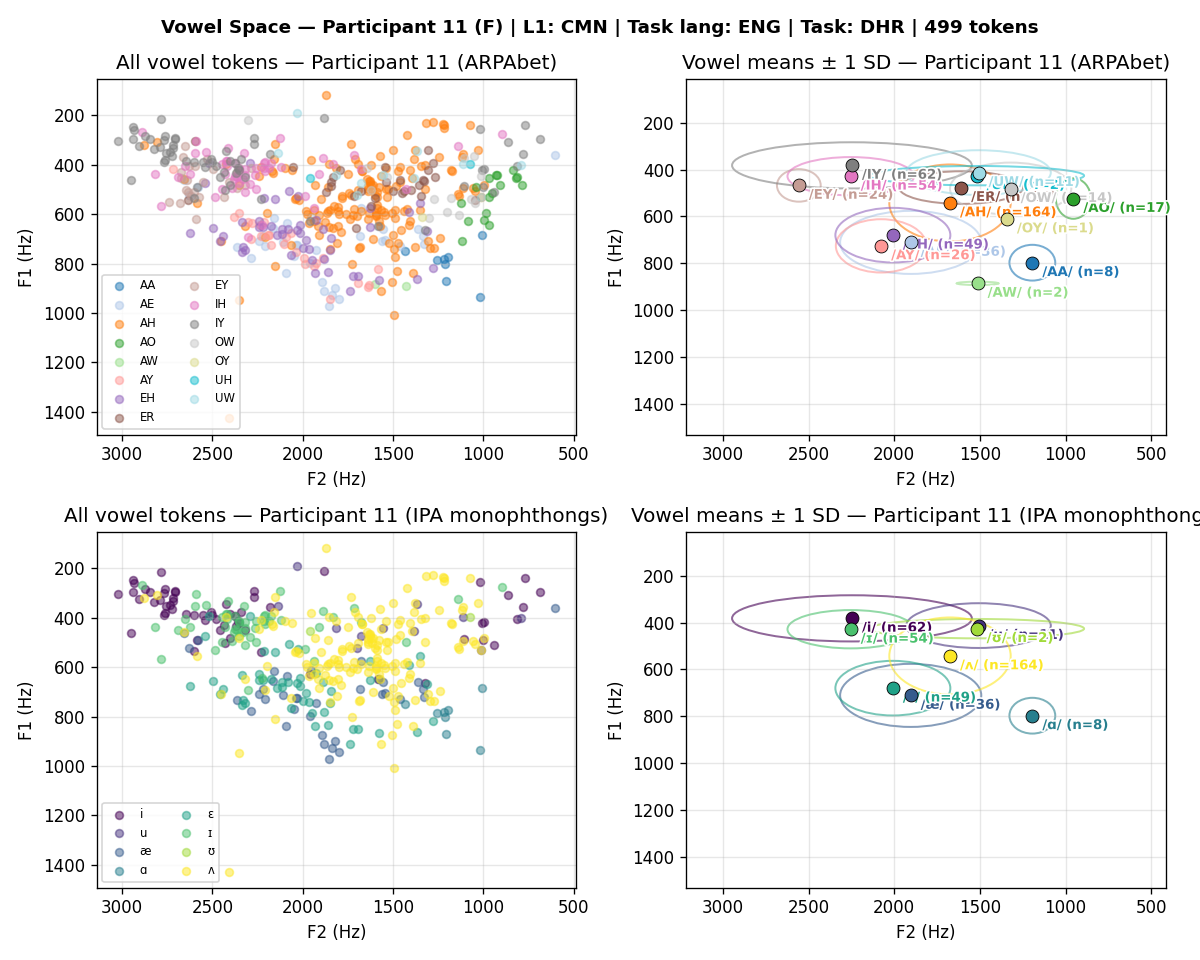

In [14]:
# ── Vowel quadrilateral plot — SINGLE participant (interactive) ──

def _plot_vowel_row(df, vowel_col, axs, title_extra,
                    cmap_name="tab20", f1_col="F1", f2_col="F2"):
    """Plot one row of vowel space: scatter (left) + means with ellipses (right)."""
    ax_scatter, ax_ellipse = axs
    cmap = plt.cm.get_cmap(cmap_name)
    unique_vowels = sorted(df[vowel_col].unique())
    vowel_colors = {v: cmap(i / max(len(unique_vowels) - 1, 1))
                    for i, v in enumerate(unique_vowels)}

    is_norm = "norm" in f1_col
    unit = "Lobanov z" if is_norm else "Hz"
    f1_label = f"F1 ({unit})"
    f2_label = f"F2 ({unit})"

    for v in unique_vowels:
        sub = df[df[vowel_col] == v]
        ax_scatter.scatter(sub[f2_col], sub[f1_col], label=v, alpha=0.5, s=22,
                           color=vowel_colors[v], picker=True)
    ax_scatter.set_xlabel(f2_label)
    ax_scatter.set_ylabel(f1_label)
    ax_scatter.set_title(f"All vowel tokens{title_extra}")
    ax_scatter.invert_xaxis()
    ax_scatter.invert_yaxis()
    ax_scatter.legend(fontsize=7, ncol=2, loc="lower left")
    ax_scatter.grid(True, alpha=0.3)

    means  = df.groupby(vowel_col)[[f1_col, f2_col]].mean()
    stds   = df.groupby(vowel_col)[[f1_col, f2_col]].std()
    counts = df.groupby(vowel_col).size()

    for v in unique_vowels:
        if v not in means.index:
            continue
        c = vowel_colors[v]
        f1_m, f2_m = means.loc[v, f1_col], means.loc[v, f2_col]
        f1_s = stds.loc[v, f1_col] if not np.isnan(stds.loc[v, f1_col]) else 0
        f2_s = stds.loc[v, f2_col] if not np.isnan(stds.loc[v, f2_col]) else 0
        n = counts.loc[v]

        if f1_s > 0 and f2_s > 0:
            ell = matplotlib.patches.Ellipse(
                (f2_m, f1_m), width=2*f2_s, height=2*f1_s,
                fill=False, edgecolor=c, linewidth=1.2, alpha=0.6,
            )
            ax_ellipse.add_patch(ell)
        ax_ellipse.scatter(f2_m, f1_m, color=c, s=60, zorder=5,
                           edgecolors="k", linewidths=0.5)
        ax_ellipse.annotate(
            f"/{v}/ (n={n})", (f2_m, f1_m),
            textcoords="offset points", xytext=(6, -8), fontsize=8, fontweight="bold",
            color=c, path_effects=[pe.withStroke(linewidth=2, foreground="white")],
        )

    ax_ellipse.set_xlabel(f2_label)
    ax_ellipse.set_ylabel(f1_label)
    ax_ellipse.set_title(f"Vowel means ± 1 SD{title_extra}")
    ax_ellipse.invert_xaxis()
    ax_ellipse.invert_yaxis()
    ax_ellipse.grid(True, alpha=0.3)

    f2_range = df[f2_col].max() - df[f2_col].min()
    f1_range = df[f1_col].max() - df[f1_col].min()
    pad = 0.08
    ax_ellipse.set_xlim(df[f2_col].max() + pad * f2_range,
                        df[f2_col].min() - pad * f2_range)
    ax_ellipse.set_ylim(df[f1_col].max() + pad * f1_range,
                        df[f1_col].min() - pad * f1_range)


def plot_vowel_space(df, title_extra="", df_ipa=None, normalized=False):
    """Vowel space plot: 1×2 when no IPA data, 2×2 with an IPA-monophthong row otherwise."""
    f1c = "F1_norm" if normalized else "F1"
    f2c = "F2_norm" if normalized else "F2"
    nrows = 2 if df_ipa is not None else 1
    fig, axs = plt.subplots(nrows, 2, figsize=(10, 4 * nrows))
    if nrows == 1:
        axs = axs[np.newaxis, :]

    _plot_vowel_row(df, "vowel", axs[0],
                    title_extra + " (ARPAbet)" if df_ipa is not None else title_extra,
                    f1_col=f1c, f2_col=f2c)

    if df_ipa is not None:
        _plot_vowel_row(df_ipa, "ipa_symbol", axs[1],
                        title_extra + " (IPA monophthongs)", cmap_name="viridis",
                        f1_col=f1c, f2_col=f2c)

    return fig

# Plot for the single selected participant
pid = row["participant_id"]
fig = plot_vowel_space(df_single, title_extra=f" — Participant {pid}",
                       df_ipa=df_single_ipa)
fig.suptitle(
    f"Vowel Space — Participant {pid} ({row['gender']}) | "
    f"L1: {row['native_language']} | Task lang: {row['task_language']} | Task: {row['task']} | "
    f"{len(df_single)} tokens",
    fontsize=11, fontweight="bold",
)
fig.tight_layout()

In [15]:
# ── Step 4: Extract F1/F2 for ALL subjects in the same folder ──
# Same L1, same task language, same task type — but all participants

l1 = row["native_language"]
task_lang = row["task_language"]
task = row["task"]

folder_mask = (
    (file_metadata["native_language"] == l1) &
    (file_metadata["task_language"] == task_lang) &
    (file_metadata["task"] == task)
)
folder_subset = file_metadata[folder_mask].copy()
print(f"Folder: L1={l1}, Task lang={task_lang}, Task={task}")
print(f"Files to process: {len(folder_subset)}")
print("=" * 60)

all_folder_formants = []

for idx_row, meta_row in folder_subset.iterrows():
    stem = meta_row["filename_stem"]
    formants = extract_vowel_formants_from_file(meta_row)
    all_folder_formants.extend(formants)
    print(f"  {stem}: {len(formants)} vowel formants")

df_folder = pd.DataFrame(all_folder_formants)
df_folder = lobanov_normalize(df_folder)
print(f"\nTotal vowel tokens with valid F1/F2: {len(df_folder)}")
print(f"Unique participants: {df_folder['participant_id'].nunique()}")
print(f"Unique vowel labels: {sorted(df_folder['vowel'].unique())}")
print()
print(df_folder.groupby("vowel")[["F1", "F2"]].agg(["mean", "std", "count"]).round(0))

df_folder_ipa = add_ipa_column(df_folder, task_lang)
if df_folder_ipa is not None:
    print(f"\n── IPA monophthong subset: {len(df_folder_ipa)} tokens, "
          f"{sorted(df_folder_ipa['ipa_symbol'].unique())} ──")
    print(df_folder_ipa.groupby("ipa_symbol")[["F1", "F2"]].agg(["mean", "std", "count"]).round(0))

# ── Gender split ──
gender_dfs = {}
gender_ipa_dfs = {}
for g in sorted(df_folder["gender"].unique()):
    gdf = df_folder[df_folder["gender"] == g]
    n_spk = gdf["participant_id"].nunique()
    gender_dfs[g] = gdf
    gender_ipa_dfs[g] = add_ipa_column(gdf, task_lang)
    print(f"\n{'─'*60}")
    print(f"Gender: {g}  |  {n_spk} speakers  |  {len(gdf)} tokens")
    print(gdf.groupby("vowel")[["F1", "F2"]].agg(["mean", "std", "count"]).round(0))
    if gender_ipa_dfs[g] is not None:
        print(f"\n  IPA subset: {len(gender_ipa_dfs[g])} tokens")
        print(gender_ipa_dfs[g].groupby("ipa_symbol")[["F1", "F2"]].agg(["mean", "std", "count"]).round(0))

Folder: L1=CMN, Task lang=ENG, Task=DHR
Files to process: 14
  ALL_005_M_CMN_ENG_DHR: 468 vowel formants
  ALL_011_F_CMN_ENG_DHR: 499 vowel formants
  ALL_012_M_CMN_ENG_DHR: 485 vowel formants
  ALL_016_M_CMN_ENG_DHR: 482 vowel formants
  ALL_018_F_CMN_ENG_DHR: 517 vowel formants
  ALL_020_M_CMN_ENG_DHR: 503 vowel formants
  ALL_021_M_CMN_ENG_DHR: 510 vowel formants
  ALL_030_F_CMN_ENG_DHR: 498 vowel formants
  ALL_032_M_CMN_ENG_DHR: 480 vowel formants
  ALL_033_M_CMN_ENG_DHR: 506 vowel formants
  ALL_035_M_CMN_ENG_DHR: 506 vowel formants
  ALL_037_M_CMN_ENG_DHR: 502 vowel formants
  ALL_039_M_CMN_ENG_DHR: 492 vowel formants
  ALL_043_M_CMN_ENG_DHR: 502 vowel formants

Total vowel tokens with valid F1/F2: 6950
Unique participants: 14
Unique vowel labels: ['AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'EH', 'ER', 'EY', 'IH', 'IY', 'OW', 'OY', 'UH', 'UW']

          F1                   F2             
        mean    std count    mean    std count
vowel                                         
AA

C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


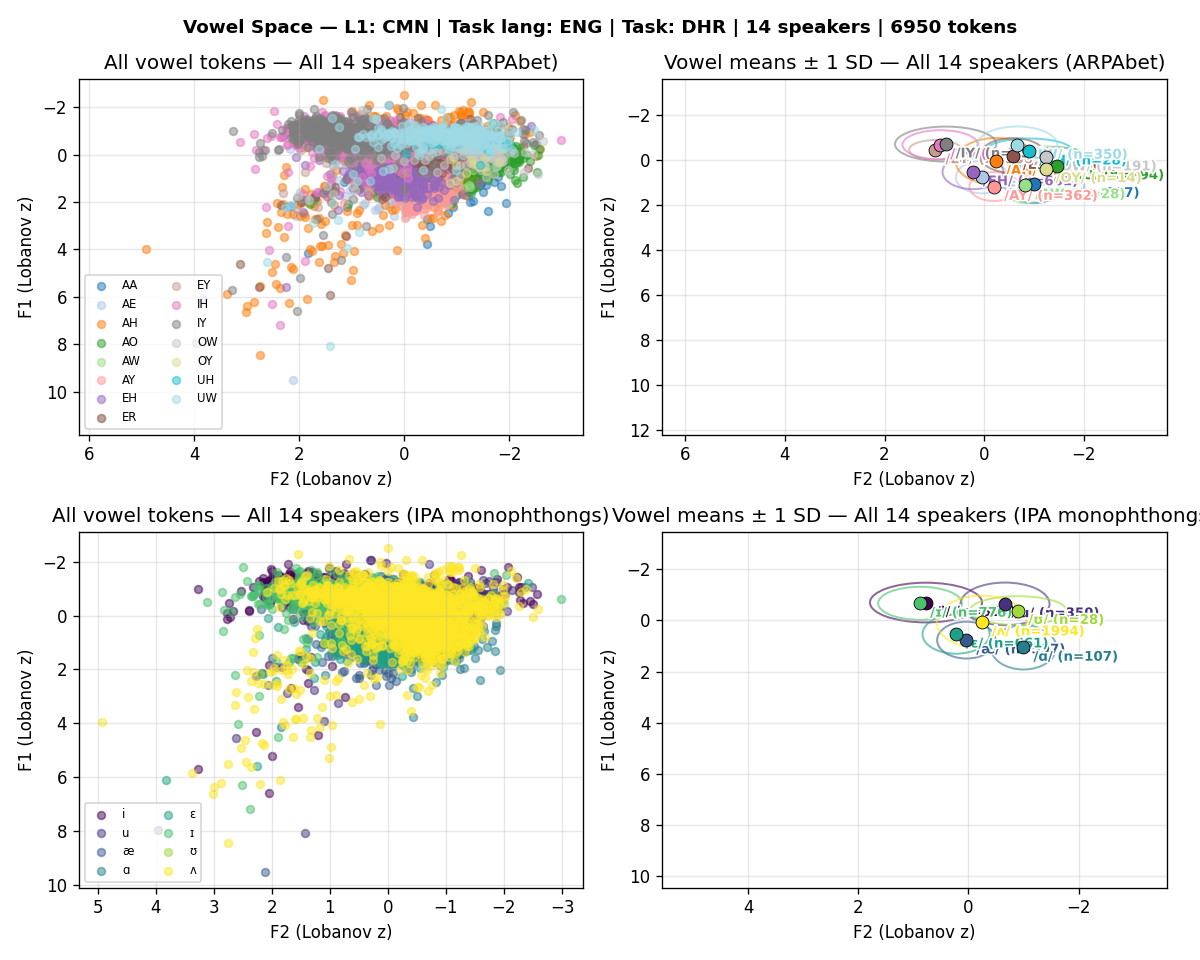

In [16]:
# ── Vowel quadrilateral plot — ALL subjects in folder (interactive) ──

# Combined plot (all genders)
n_speakers = df_folder["participant_id"].nunique()
fig = plot_vowel_space(df_folder, title_extra=f" — All {n_speakers} speakers",
                       df_ipa=df_folder_ipa, normalized=True)
fig.suptitle(
    f"Vowel Space — L1: {l1} | Task lang: {task_lang} | Task: {task} | "
    f"{n_speakers} speakers | {len(df_folder)} tokens",
    fontsize=11, fontweight="bold",
)
fig.tight_layout()
plt.show()

C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


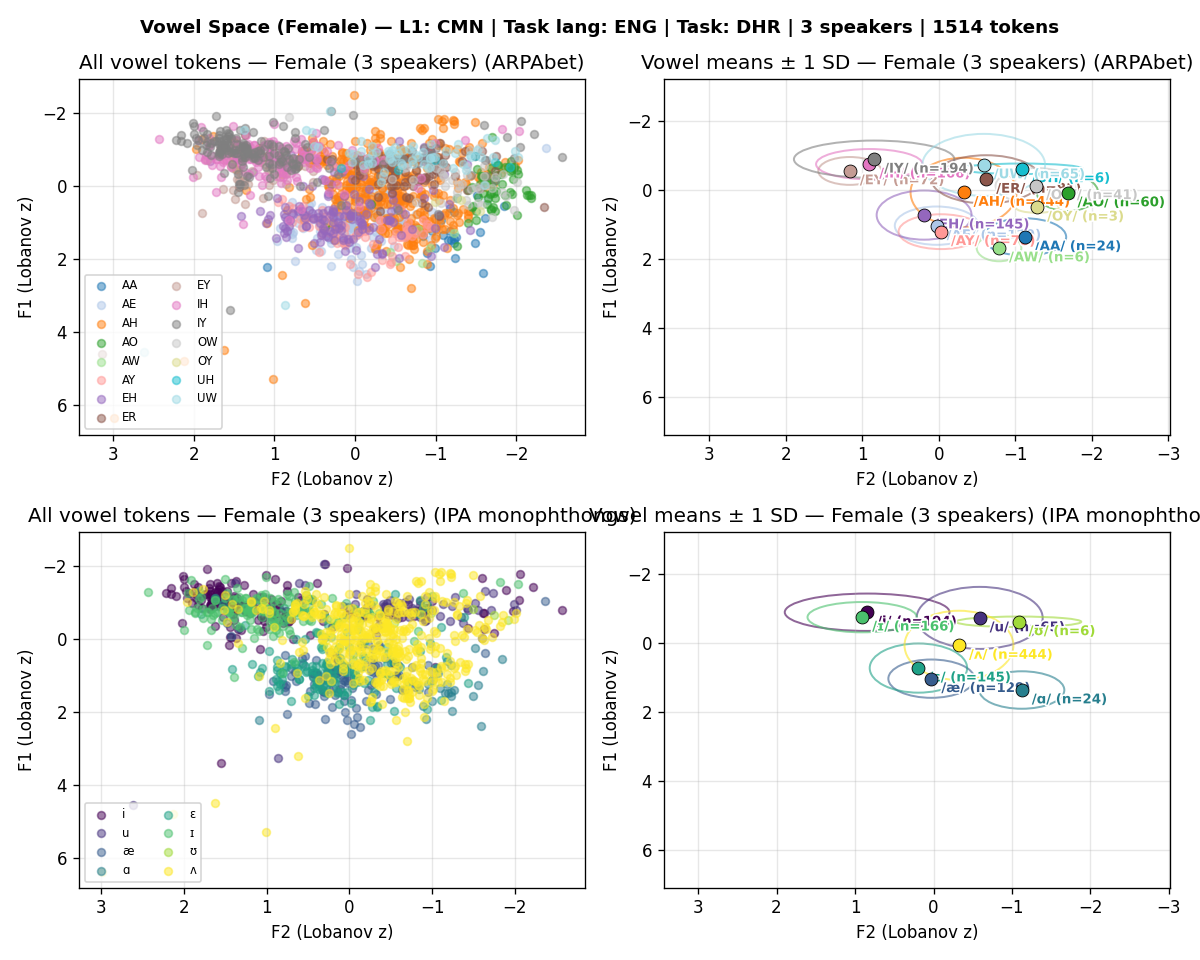

In [17]:
# ── Vowel quadrilateral plot — Female speakers only ──

if "F" in gender_dfs:
    gdf = gender_dfs["F"]
    n_spk = gdf["participant_id"].nunique()
    fig_f = plot_vowel_space(gdf, title_extra=f" — Female ({n_spk} speakers)",
                             df_ipa=gender_ipa_dfs["F"], normalized=True)
    fig_f.suptitle(
        f"Vowel Space (Female) — L1: {l1} | Task lang: {task_lang} | "
        f"Task: {task} | {n_spk} speakers | {len(gdf)} tokens",
        fontsize=11, fontweight="bold",
    )
    fig_f.tight_layout()
    plt.show()
else:
    print("No female speakers in this subset.")

C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)
C:\Users\BatLab\AppData\Local\Temp\ipykernel_20444\2911401588.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


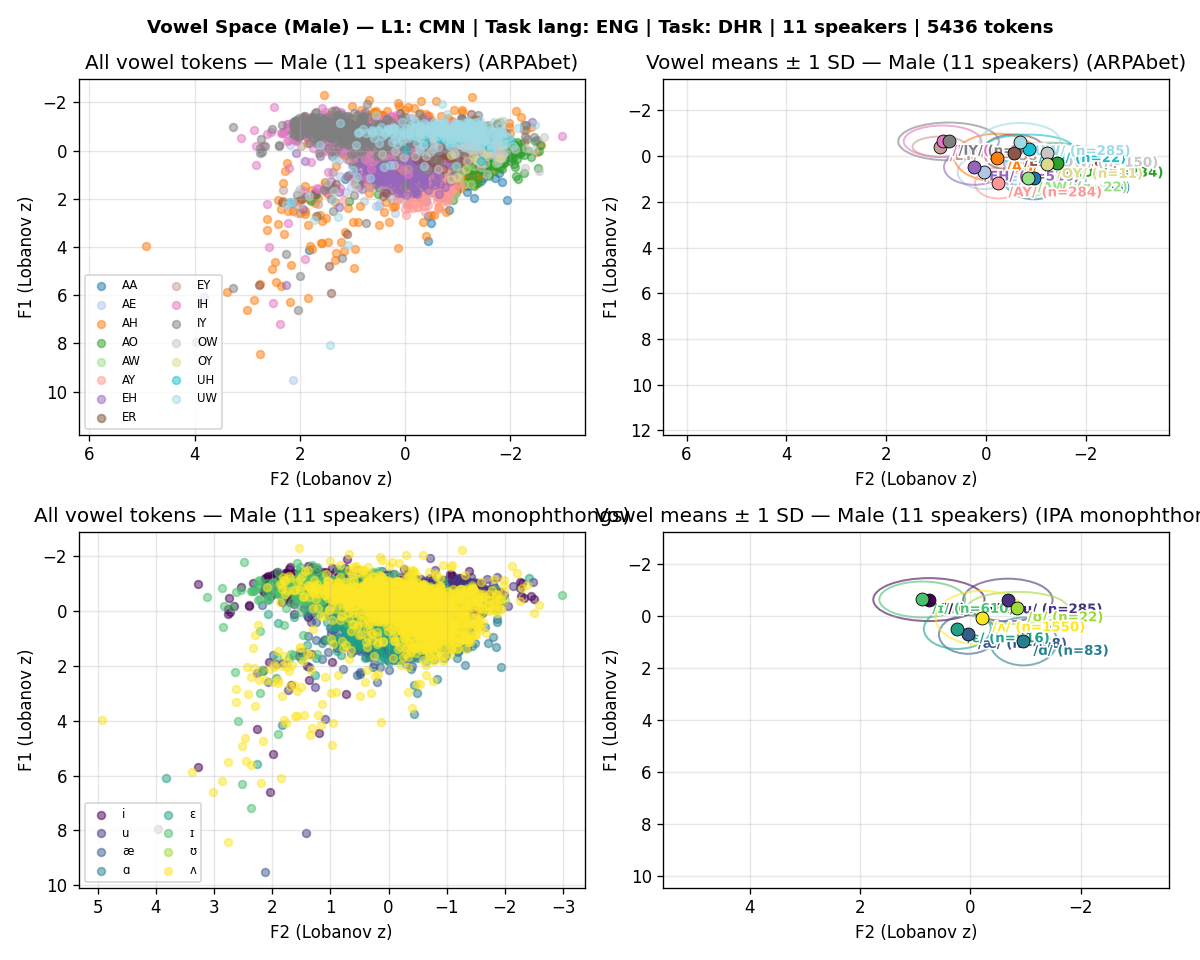

In [18]:
# ── Vowel quadrilateral plot — Male speakers only ──

if "M" in gender_dfs:
    gdf = gender_dfs["M"]
    n_spk = gdf["participant_id"].nunique()
    fig_m = plot_vowel_space(gdf, title_extra=f" — Male ({n_spk} speakers)",
                             df_ipa=gender_ipa_dfs["M"], normalized=True)
    fig_m.suptitle(
        f"Vowel Space (Male) — L1: {l1} | Task lang: {task_lang} | "
        f"Task: {task} | {n_spk} speakers | {len(gdf)} tokens",
        fontsize=11, fontweight="bold",
    )
    fig_m.tight_layout()
    plt.show()
else:
    print("No male speakers in this subset.")